# AA-UTE 2026

## P6 - Forecasting con modelos fundacionales

Este practico se centra en el uso de modelos de forecasting basados en modelos fundacionales.  
Se trabajará sobre una serie de datos reales correspondiente a la demanda de energía eléctrica en la ciudad de Mercedes, Soriano.  
Los modelos a utilizar serán de la librería `darts`.

Al finalizar este practico se espera que el estudiante haya podido experimentar con:

- implementar un modelo de forecasting (`Chronos2`) para forecasting;
- implementar un modelo de árboles (`XGBoost`) para forecasting y compararlo con el modelo fundacional;
- implementar un modelo de aprendizaje profundo (`TCN`) para forecasting y compararlo con el modelo fundacional;

### Trabajo a realizar

Este notebook esta pensado para que al principio se puedan correr las diferentes celdas tal y como están y analizar los resultados. Luego, se proponen algunas modificaciones para que el estudiante pueda experimentar con los modelos y analizar los resultados.

In [1]:
import warnings
import logging

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
)

from darts.utils.callbacks import TFMProgressBar
from darts.metrics import mae
from torch.nn import MSELoss

from darts.models import XGBModel
from darts.models import TCNModel
from darts.models import Chronos2Model
from darts import TimeSeries

# Otros modelos fundacionales se pueden importar de la misma forma:
# from darts.models import TimesFM2p5Model
# from darts.models import TiRexModel  # requires: pip install tirex-ts>=1.4.0

warnings.filterwarnings("ignore")
logging.disable(logging.CRITICAL)

SEED = 42
np.random.seed(SEED)

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (14, 4)

## Parte 1 - Serie base y extraccion de caracteristicas

Primero cargamos los datos. Utilizaremos los mismos datos que en el práctico 4 de forecasting.

In [2]:
# ---------------------------------------------------------------
# 1. Carga de datos
#   - Se cargan los datos que contiene la serie de tiempo a una frecuencia de 15 minutos.
#   - Se convierten los timestamps a formato datetime y se setea como índice del dataframe.
#   - Se remueven columnas innecesarias y se re-muestrea la serie a frecuencia horaria.  
# ---------------------------------------------------------------
path_file = "./DATOS_15MIN_MER_trainset-labeled.csv" # puede que sea necesario cambiar la ruta de este archivo.
dta = pd.read_csv(path_file, low_memory=False)
dta["timestamp"] = pd.to_datetime(dta["timestamp"])
dta.set_index("timestamp", inplace=True)
dta = dta[dta.index < '2024-04-01']
dta = dta[dta["series"]=="OFI"]
dta = dta.drop(columns=["series", "label"])
dta = dta.resample("h").mean()

print(dta.head())

                              value
timestamp                          
2015-04-14 00:00:00+00:00  5.076925
2015-04-14 01:00:00+00:00  4.490550
2015-04-14 02:00:00+00:00  4.210925
2015-04-14 03:00:00+00:00  4.065475
2015-04-14 04:00:00+00:00  4.026950


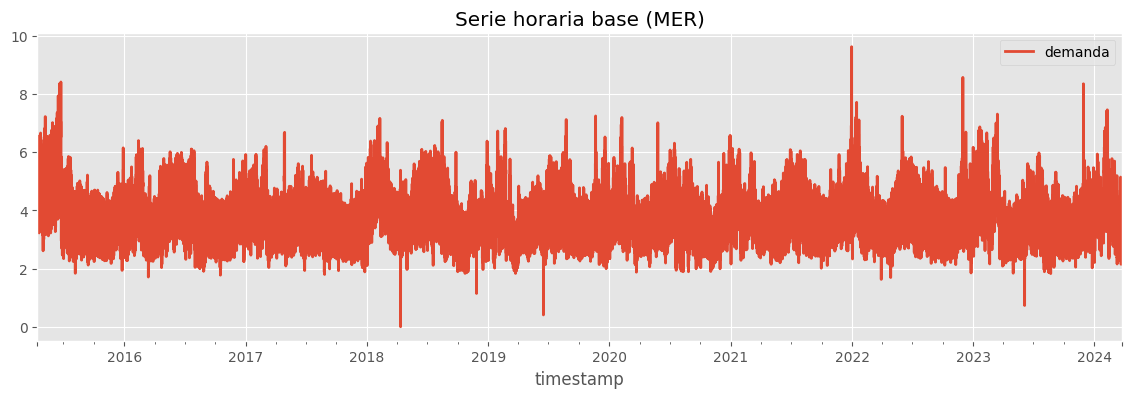

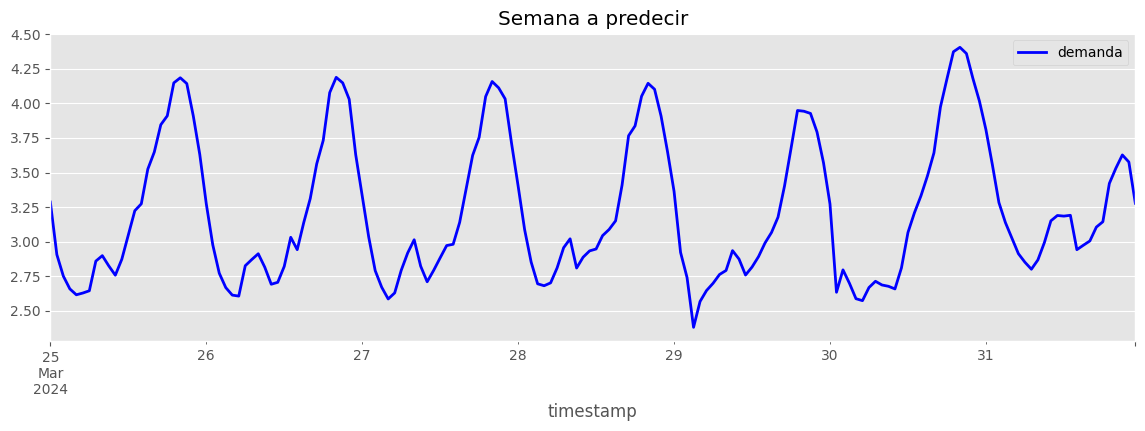

In [3]:
ts = TimeSeries.from_dataframe(dta).astype("float32")
train, val = ts.split_before(len(dta) - 7 * 24)

# Buscamos predecir 7 días a partir de los últimos 30 días
INPUT_CHUNK_LENGTH = 30 * 24
OUTPUT_CHUNK_LENGTH = 7 * 24

train.plot(label="demanda", title="Serie horaria base (MER)")
plt.show()
val.plot(label="demanda", color="b", title="Semana a predecir")
plt.show()

Definición de funciones útiles para más adelante

In [4]:
# Métricas de evaluación para los modelos de forecasting.
def metricas(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred),
        "MAPE": mean_absolute_percentage_error(y_true, y_pred),
    }

## Parte 2 - Forecasting con Machine Learning

### Forecasting de una semana con XGBoost

In [5]:
# Definición del modelo
xgb_1w = XGBModel(
    lags=INPUT_CHUNK_LENGTH,
    n_estimators=50,
    max_depth=6,
    tree_method="hist",
    random_state=SEED,
    n_jobs=1,
)

In [6]:
# Entrenamiento
t0 = time.perf_counter()
xgb_1w.fit(train)
xgb_1w_train_time = time.perf_counter() - t0
print(f"Tiempo de entrenamiento XGB 1h: {xgb_1w_train_time:.2f} segundos")

Tiempo de entrenamiento XGB 1h: 37.67 segundos


In [7]:
# Predicción
pred_xgb_1w = xgb_1w.predict(n=OUTPUT_CHUNK_LENGTH)

In [8]:
# Métricas
metrics_xgb_1w = metricas(val.values(), pred_xgb_1w.values())
print(metrics_xgb_1w)

{'MAE': 0.26975104212760925, 'MSE': 0.12409237772226334, 'MAPE': 0.08603620529174805}


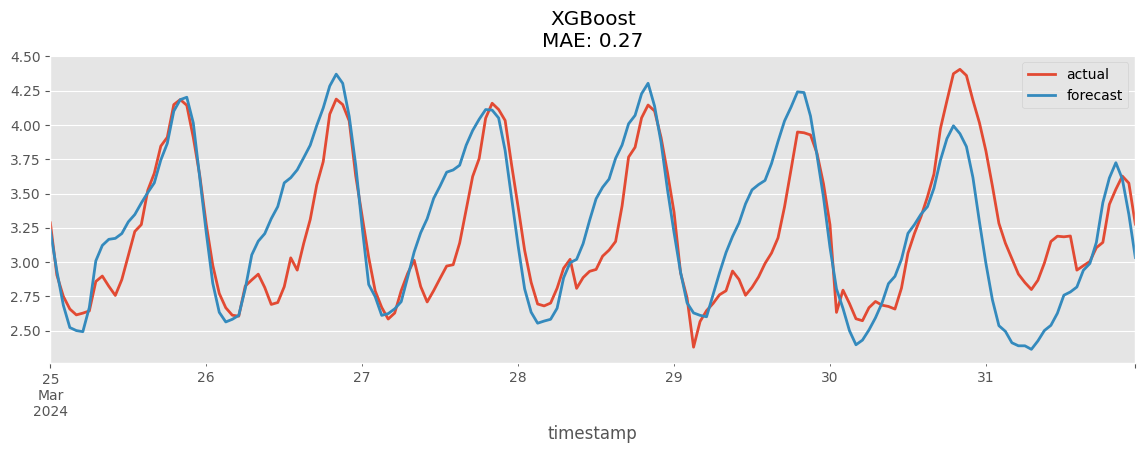

In [9]:
# Gráficas
val[-3 * OUTPUT_CHUNK_LENGTH :].plot(label="actual")
pred_xgb_1w.plot(label="forecast", title=f"XGBoost\nMAE: {mae(val, pred_xgb_1w):.2f}");

## Parte 3 - Forecasting con Deep Learning

### Forecasting de una semana con TCN

In [19]:
# Configuración para correr los modelos torch en CPU, y deshabilitar las barras de progreso para todas las etapas menos entrenamiento.
import torch
def generate_torch_kwargs():
    accelerator = "gpu" if torch.cuda.is_available() else "cpu"

    return {
        "pl_trainer_kwargs": {
            "accelerator": accelerator,
            "callbacks": [TFMProgressBar()],
        }
    }

In [23]:
# Se instancia un modelo TCN para el problema de forecasting de 1 semana.
tcn_1w = TCNModel(
    input_chunk_length=168*2,
    output_chunk_length=OUTPUT_CHUNK_LENGTH,
    n_epochs=2,
    dropout=0.1,
    dilation_base=2,
    weight_norm=True,
    kernel_size=5,
    random_state=SEED,
    loss_fn=MSELoss(),
    save_checkpoints=True,
    force_reset=True,
    **generate_torch_kwargs(),
)

In [24]:
# Entrenamiento
t0 = time.perf_counter()
tcn_1w.fit(train, verbose=True)
tcn_1w_train_time = time.perf_counter() - t0
print(f"Tiempo de entrenamiento TCN: {tcn_1w_train_time:.2f} segundos")

Sanity Checking: 0it [00:00, ?it/s]

Training: 0it [00:00, ?it/s]

Tiempo de entrenamiento TCN: 173.62 segundos


In [25]:
# Predicción
pred_tcn_1w = tcn_1w.predict(n=OUTPUT_CHUNK_LENGTH)

Predicting: 0it [00:00, ?it/s]

In [26]:
# Métricas
metrics_tcn_1w = metricas(val.values(), pred_tcn_1w.values())
print(metrics_tcn_1w)

{'MAE': 0.38198480010032654, 'MSE': 0.22557489573955536, 'MAPE': 0.1235378235578537}


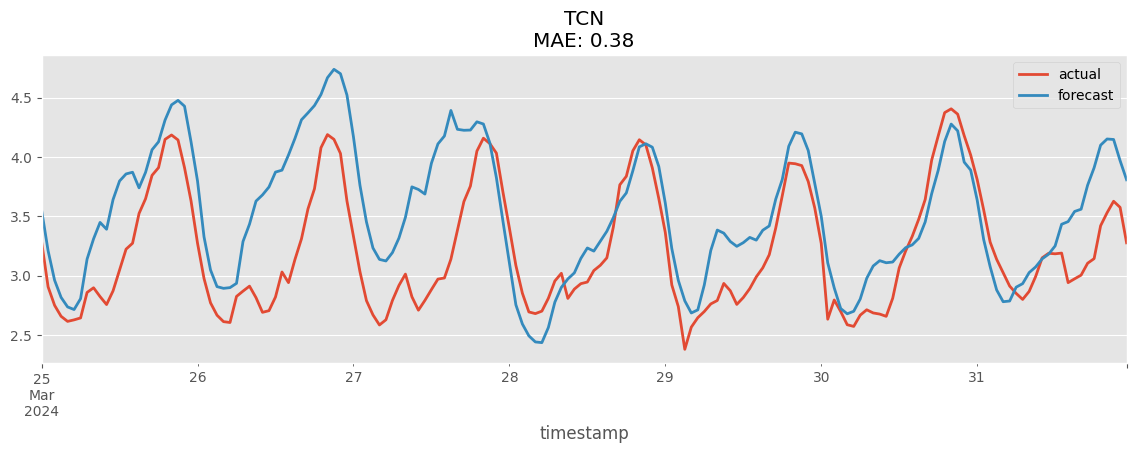

In [27]:
# Gráficas
val.plot(label="actual")
pred_tcn_1w.plot(label="forecast", title=f"TCN\nMAE: {mae(val, pred_tcn_1w):.2f}");

## Parte 4 - Forecasting con Modelos Fundacionales

### Forecasting de una semana con Chronos

In [28]:
# Creamos un directorio donde se van a guardar los pesos del modelo
local_dir="./cache"
!mkdir -p ./cache

La sintaxis del comando no es correcta.


In [ ]:
# El modelo Chronos2 pesa unos 500MB aprox.
# Si prefiere usar una variante más liviana del modelo, 
# puede usarse el chronos-2-small descomentando la línea "hub_model_name".

# Usaremos hasta 30 días de datos para predecir los próximos 7 días
model_chronos = Chronos2Model(
    input_chunk_length=(1, 30 * 24),
    output_chunk_length=OUTPUT_CHUNK_LENGTH,
    hub_model_name="autogluon/chronos-2-small",
    local_dir=local_dir,
)

Llamamos al método `.fit()` para "entrenar" el modelo con los datos de entrada.  
Notar que no se está entrenando el modelo, ni realizando fine-tuning, ya que el modelo ya se encuentra pre-entrenado. Lo que hace este método es indicarle la serie objetivo sobre la cual realizar la predicción.

In [123]:
# Definir cuántas horas hacia atrás, de la serie objetivo, quiero que vea el modelo fundacional
# Por ejemplo: 168 * 4 serían las 4 semanas previas a la predicción
cant_horas = 168*4 
cant_horas_10 = 168*10
cant_horas_40 = 168*120


In [105]:
# Entrenamiento
t0 = time.perf_counter()
model_chronos.fit(series=train[-cant_horas:], verbose=True)
chronos_1w_train_time = time.perf_counter() - t0
print(f'Tiempo de "entrenamiento" Chronos: {chronos_1w_train_time:.2f} segundos')

Tiempo de "entrenamiento" Chronos: 0.10 segundos


In [107]:
# Entrenamiento_10
t0 = time.perf_counter()
model_chronos.fit(series=train[-cant_horas_10:], verbose=True)
chronos_1w_train_time_10 = time.perf_counter() - t0
print(f'Tiempo de "entrenamiento" Chronos: {chronos_1w_train_time:.2f} segundos')

Tiempo de "entrenamiento" Chronos: 0.10 segundos


In [124]:
# Entrenamiento_40
t0 = time.perf_counter()
model_chronos.fit(series=train[-cant_horas_40:], verbose=True)
chronos_1w_train_time_40 = time.perf_counter() - t0
print(f'Tiempo de "entrenamiento" Chronos: {chronos_1w_train_time:.2f} segundos')

Tiempo de "entrenamiento" Chronos: 0.10 segundos


In [109]:
# Predicción
pred_chronos_1w = model_chronos.predict(
    n=168,
    series=train[-cant_horas:],
    verbose=False,
)

In [110]:
# Predicción_10
pred_chronos_1w_10 = model_chronos.predict(
    n=168,
    series=train[-cant_horas_10:],
    verbose=False,
)

In [125]:
# Predicción_40
pred_chronos_1w_40 = model_chronos.predict(
    n=168,
    series=train[-cant_horas_40:],
    verbose=False,
)

In [112]:
# Métricas
metrics_chronos_1w = metricas(val.values(), pred_chronos_1w.values())
print(metrics_chronos_1w)

{'MAE': 0.164484903216362, 'MSE': 0.045618388801813126, 'MAPE': 0.050685394555330276}


In [113]:
# Métricas_10
metrics_chronos_1w_10 = metricas(val.values(), pred_chronos_1w_10.values())
print(metrics_chronos_1w_10)

{'MAE': 0.15895691514015198, 'MSE': 0.042283277958631516, 'MAPE': 0.04943766072392464}


In [126]:
# Métricas_40
metrics_chronos_1w_40 = metricas(val.values(), pred_chronos_1w_40.values())
print(metrics_chronos_1w_40)

{'MAE': 0.15895691514015198, 'MSE': 0.042283277958631516, 'MAPE': 0.04943766072392464}


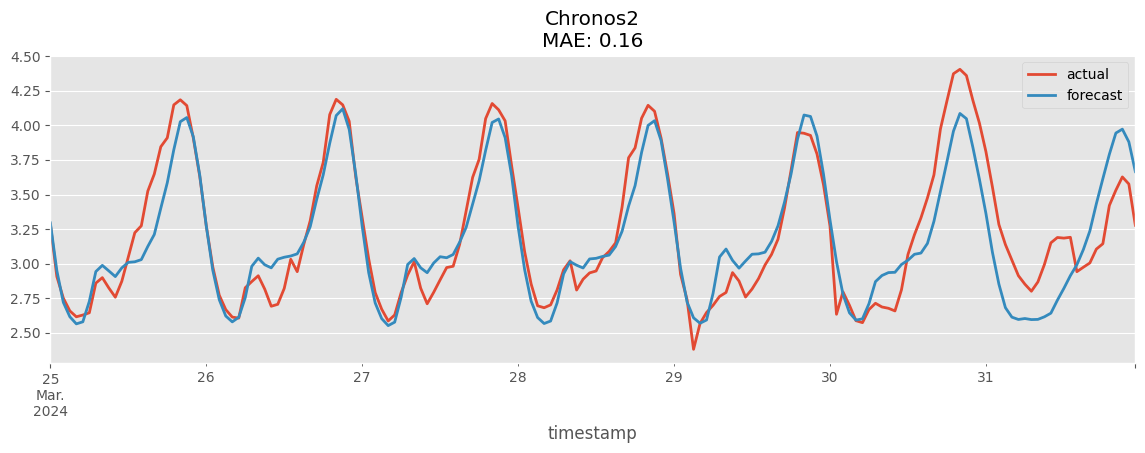

In [121]:
# Gráficas
val.plot(label="actual")
pred_chronos_1w.plot(label="forecast", title=f"Chronos2\nMAE: {mae(val, pred_chronos_1w):.2f}");

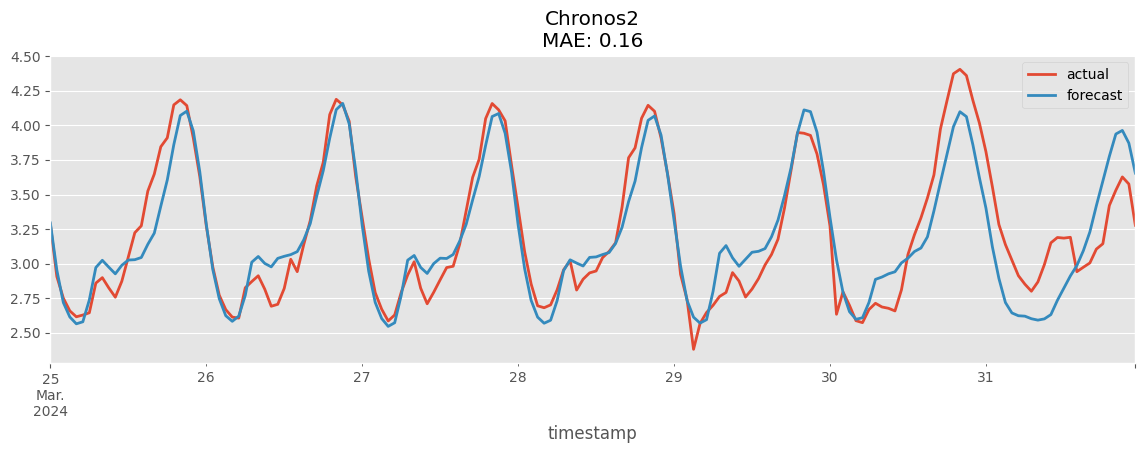

In [120]:
# Gráficas_10
val.plot(label="actual")
pred_chronos_1w_10.plot(label="forecast", title=f"Chronos2\nMAE: {mae(val, pred_chronos_1w_10):.2f}");

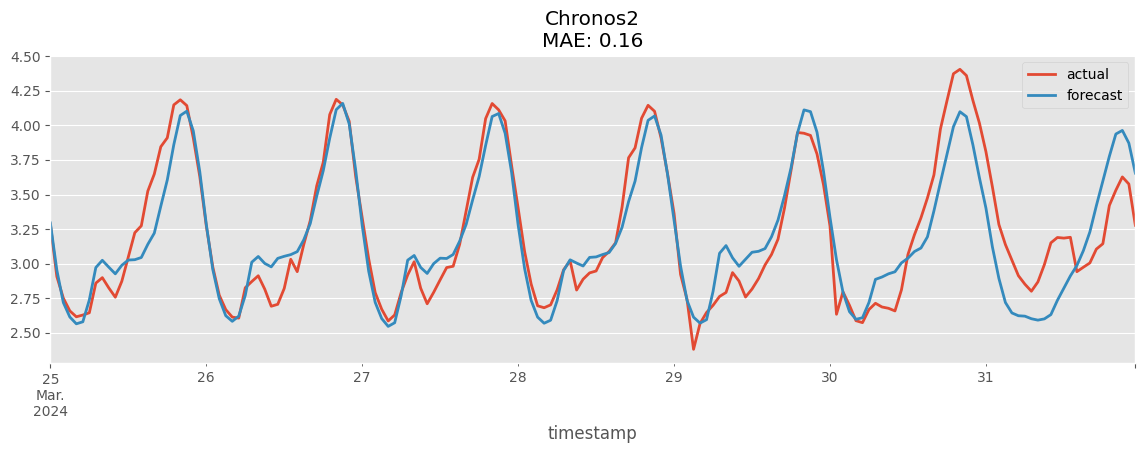

In [119]:
# Gráficas_40
val.plot(label="actual")
pred_chronos_1w_40.plot(label="forecast", title=f"Chronos2\nMAE: {mae(val, pred_chronos_1w_40):.2f}");

## Parte 5 - Comparación global

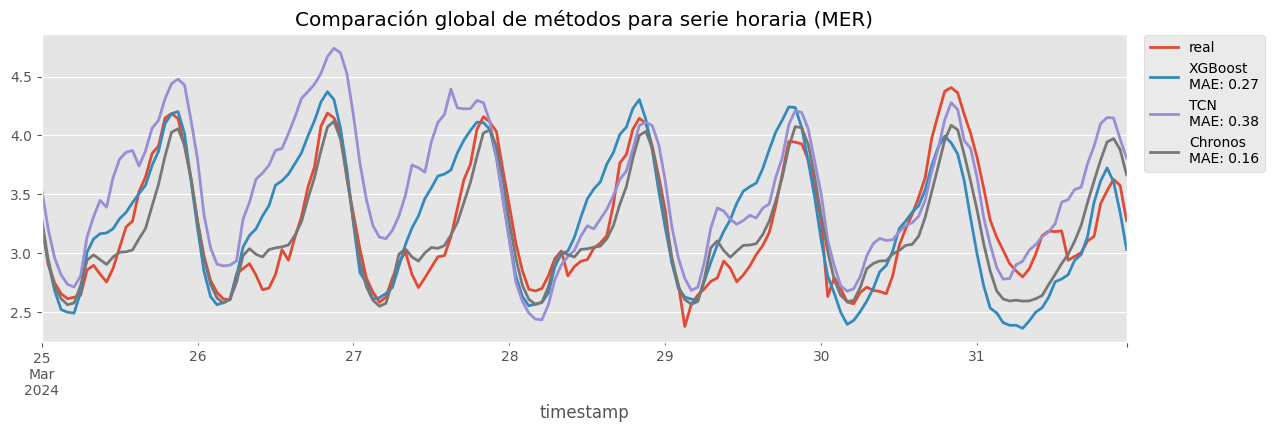

In [39]:
# Gráficas
val.plot(label="real")
pred_xgb_1w.plot(label=f"XGBoost\nMAE: {mae(val, pred_xgb_1w):.2f}");
pred_tcn_1w.plot(label=f"TCN\nMAE: {mae(val, pred_tcn_1w):.2f}");
pred_chronos_1w.plot(label=f"Chronos\nMAE: {mae(val, pred_chronos_1w):.2f}", title="Comparación global de métodos para serie horaria (MER)");
plt.legend(bbox_to_anchor=(1.01, 1.02))
plt.show()

In [40]:
# Comparación global para el problema de forecasting de 1 semana.

pd.DataFrame([
    {"modelo": "XGBoost", "MAE": metrics_xgb_1w["MAE"], "MAPE": metrics_xgb_1w["MAPE"], "MSE": metrics_xgb_1w["MSE"], "train_time": xgb_1w_train_time},
    {"modelo": "TCN_1w", "MAE": metrics_tcn_1w["MAE"], "MAPE": metrics_tcn_1w["MAPE"], "MSE": metrics_tcn_1w["MSE"], "train_time": tcn_1w_train_time},
    {"modelo": "Chronos2", "MAE": metrics_chronos_1w["MAE"], "MAPE": metrics_chronos_1w["MAPE"], "MSE": metrics_chronos_1w["MSE"], "train_time": chronos_1w_train_time},
])

,modelo,MAE,MAPE,MSE,train_time
0,XGBoost,0.269751,0.086036,0.124092,37.669132
1,TCN_1w,0.381985,0.123538,0.225575,173.619892
2,Chronos2,0.164485,0.050685,0.045618,45.852197
